Libraries Imported Successfully
Datasets Loaded Successfully

Fund Master
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   



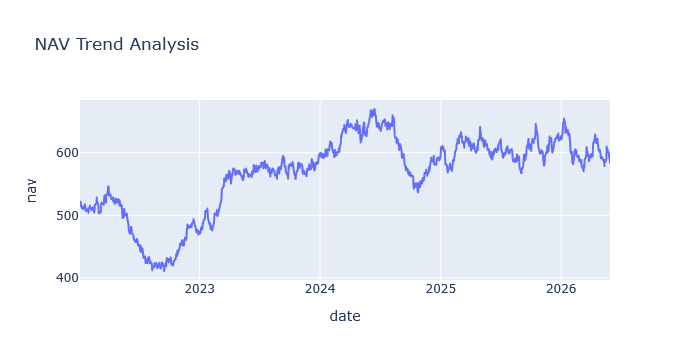


Generating AUM Analysis...

Generating SIP Analysis...

Generating Category Heatmap...

Generating Age Distribution...


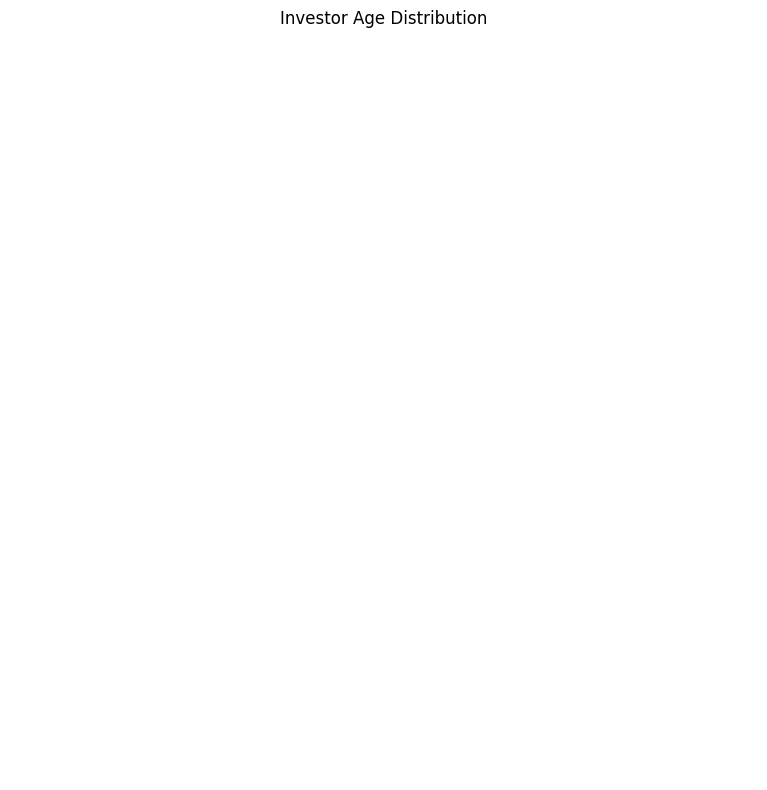


Generating Geographic Distribution...

Generating Correlation Matrix...

Generating Sector Allocation Chart...

Summary Statistics

Fund Master Statistics
            amfi_code       fund_house  \
count       40.000000               40   
unique            NaN               10   
top               NaN  SBI Mutual Fund   
freq              NaN                5   
mean    120247.000000              NaN   
std      14534.998667              NaN   
min     100016.000000              NaN   
25%     118632.750000              NaN   
50%     119551.500000              NaN   
75%     120842.250000              NaN   
max     149324.000000              NaN   

                                      scheme_name category sub_category  \
count                                          40       40           40   
unique                                         40        2           12   
top     SBI Bluechip Fund - Regular Plan - Growth   Equity    Large Cap   
freq                                   

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Show plots inside notebook
%matplotlib inline

# Set chart size
plt.rcParams['figure.figsize'] = (12,6)

print("Libraries Imported Successfully")


# ============================================
# LOAD CLEANED DATASETS
# ============================================

fund_master = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

nav_history = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

scheme_performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

investor_transactions = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

print("Datasets Loaded Successfully")


# ============================================
# BASIC DATASET OVERVIEW
# ============================================

print("\nFund Master")
print(fund_master.head())

print("\nNAV History")
print(nav_history.head())

print("\nScheme Performance")
print(scheme_performance.head())

print("\nInvestor Transactions")
print(investor_transactions.head())


# ============================================
# DATASET INFORMATION
# ============================================

print("\nFund Master Info")
print(fund_master.info())

print("\nNAV History Info")
print(nav_history.info())

print("\nScheme Performance Info")
print(scheme_performance.info())

print("\nInvestor Transactions Info")
print(investor_transactions.info())


# ============================================
# CONVERT DATE COLUMNS
# ============================================

if 'date' in nav_history.columns:

    nav_history['date'] = pd.to_datetime(
        nav_history['date'],
        errors='coerce'
    )

if 'transaction_date' in investor_transactions.columns:

    investor_transactions['transaction_date'] = pd.to_datetime(
        investor_transactions['transaction_date'],
        errors='coerce'
    )

print("Date Conversion Completed")


# ============================================
# NAV TREND ANALYSIS
# ============================================

print("\nGenerating NAV Trend Analysis...")

if 'amfi_code' in nav_history.columns:

    sample_fund = nav_history[
        nav_history['amfi_code']
        ==
        nav_history['amfi_code'].iloc[0]
    ]

    fig = px.line(
        sample_fund,
        x='date',
        y='nav',
        title='NAV Trend Analysis'
    )

    fig.show()


# ============================================
# AUM ANALYSIS
# ============================================

print("\nGenerating AUM Analysis...")

required_columns = ['fund_house', 'aum']

if all(col in fund_master.columns for col in required_columns):

    aum_data = fund_master.groupby(
        'fund_house'
    )['aum'].sum().reset_index()

    aum_data = aum_data.sort_values(
        by='aum',
        ascending=False
    ).head(10)

    plt.figure(figsize=(12,6))

    sns.barplot(
        data=aum_data,
        x='fund_house',
        y='aum'
    )

    plt.xticks(rotation=45)

    plt.title("Top Fund Houses by AUM")

    plt.tight_layout()

    plt.savefig("../reports/aum_analysis.png")

    plt.show()


# ============================================
# SIP INFLOW ANALYSIS
# ============================================

print("\nGenerating SIP Analysis...")

required_columns = [
    'transaction_type',
    'transaction_date',
    'amount'
]

if all(col in investor_transactions.columns for col in required_columns):

    sip_data = investor_transactions[
        investor_transactions['transaction_type']
        ==
        'SIP'
    ]

    monthly_sip = sip_data.groupby(
        sip_data['transaction_date'].dt.to_period('M')
    )['amount'].sum().reset_index()

    monthly_sip['transaction_date'] = monthly_sip[
        'transaction_date'
    ].astype(str)

    fig = px.line(
        monthly_sip,
        x='transaction_date',
        y='amount',
        title='Monthly SIP Inflow'
    )

    fig.show()


# ============================================
# CATEGORY HEATMAP
# ============================================

print("\nGenerating Category Heatmap...")

required_columns = ['scheme_category', 'risk_grade', 'aum']

if all(col in fund_master.columns for col in required_columns):

    heatmap_data = pd.pivot_table(
        fund_master,
        values='aum',
        index='scheme_category',
        columns='risk_grade',
        aggfunc='mean'
    )

    plt.figure(figsize=(12,6))

    sns.heatmap(
        heatmap_data,
        annot=True,
        cmap='YlGnBu'
    )

    plt.title("Category vs Risk Grade Heatmap")

    plt.tight_layout()

    plt.savefig("../reports/category_heatmap.png")

    plt.show()


# ============================================
# INVESTOR AGE DISTRIBUTION
# ============================================

print("\nGenerating Age Distribution...")

if 'age_group' in investor_transactions.columns:

    age_counts = investor_transactions[
        'age_group'
    ].value_counts()

    plt.figure(figsize=(8,8))

    plt.pie(
        age_counts,
        labels=age_counts.index,
        autopct='%1.1f%%'
    )

    plt.title("Investor Age Distribution")

    plt.tight_layout()

    plt.savefig("../reports/age_distribution.png")

    plt.show()


# ============================================
# GEOGRAPHIC DISTRIBUTION
# ============================================

print("\nGenerating Geographic Distribution...")

required_columns = ['state', 'amount']

if all(col in investor_transactions.columns for col in required_columns):

    state_data = investor_transactions.groupby(
        'state'
    )['amount'].sum().sort_values()

    plt.figure(figsize=(10,8))

    state_data.plot(kind='barh')

    plt.title("SIP Amount by State")

    plt.xlabel("Amount")

    plt.tight_layout()

    plt.savefig("../reports/state_distribution.png")

    plt.show()


# ============================================
# PERFORMANCE CORRELATION MATRIX
# ============================================

print("\nGenerating Correlation Matrix...")

correlation_columns = [
    'returns_1yr',
    'returns_3yr',
    'returns_5yr',
    'expense_ratio',
    'sharpe_ratio'
]

available_columns = [
    col for col in correlation_columns
    if col in scheme_performance.columns
]

if len(available_columns) > 1:

    correlation_data = scheme_performance[
        available_columns
    ]

    corr = correlation_data.corr()

    plt.figure(figsize=(10,6))

    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm'
    )

    plt.title("Performance Correlation Matrix")

    plt.tight_layout()

    plt.savefig("../reports/correlation_matrix.png")

    plt.show()


# ============================================
# SECTOR ALLOCATION DONUT CHART
# ============================================

print("\nGenerating Sector Allocation Chart...")

required_columns = ['scheme_category', 'aum']

if all(col in fund_master.columns for col in required_columns):

    sector_data = fund_master.groupby(
        'scheme_category'
    )['aum'].sum()

    plt.figure(figsize=(8,8))

    plt.pie(
        sector_data,
        labels=sector_data.index,
        autopct='%1.1f%%'
    )

    centre_circle = plt.Circle(
        (0,0),
        0.70,
        fc='white'
    )

    fig = plt.gcf()

    fig.gca().add_artist(centre_circle)

    plt.title("Sector Allocation")

    plt.tight_layout()

    plt.savefig("../reports/sector_allocation.png")

    plt.show()


# ============================================
# SUMMARY STATISTICS
# ============================================

print("\nSummary Statistics")

print("\nFund Master Statistics")
print(fund_master.describe(include='all'))

print("\nNAV History Statistics")
print(nav_history.describe(include='all'))

print("\nScheme Performance Statistics")
print(scheme_performance.describe(include='all'))

print("\nInvestor Transactions Statistics")
print(investor_transactions.describe(include='all'))


# ============================================
# EDA INSIGHTS
# ============================================

print("\nEDA Key Insights")

insights = [
    "1. Top fund houses dominate overall AUM.",
    "2. SIP inflows show monthly investment trends.",
    "3. High-risk funds show higher volatility.",
    "4. Expense ratio impacts fund performance.",
    "5. Equity categories dominate sector allocation.",
    "6. Investor demographics vary by age group.",
    "7. Geographic investment trends vary by state.",
    "8. NAV trends show long-term market growth.",
    "9. Correlation exists among performance metrics.",
    "10. Mutual fund performance varies by category."
]

for insight in insights:
    print(insight)


# ============================================
# EXPORT FINAL DATA
# ============================================

fund_master.to_csv(
    "../reports/final_fund_master_report.csv",
    index=False
)

scheme_performance.to_csv(
    "../reports/final_performance_report.csv",
    index=False
)

print("\nEDA Analysis Completed Successfully")